# Análisis de esfuerzos y deformaciones para una viga por el método de los elementos finitos (FEM)

--- 
Hecho por:

**Michael Heredia Pérez**
- [mherediap@unal.edu.co](mherediap@unal.edu.co)
- Docente

**Sergio Daniel Martinez Segura**
- [semartinezse@unal.edu.co](semartinezse@unal.edu.co)
- Monitor (Ingeniería Civil)

Fecha: 2026-03-07

Universidad Nacional de Colombia sede Manizales

---

## El problema

El presente estudio tiene como objetivo modelar el comportamiento estructural de una viga de concreto de sección rectangular sujeta a una carga distribuida parcial. La viga cuenta con una longitud total de 3.0 m, compuesta por un tramo central de 2.0 m entre apoyos y un voladizo de 1.0 m, además, cuenta con una altura de 0.7 m y espesor de 0.1 m. Sometida a una carga uniforme de 10 kN/m desde $x$ = 1.0 hasta el final del voladizo.

Para la solución numérica, se utiliza la formulación de Elasticidad Plana (Esfuerzo Plano). Se implementa el elemento cuadrilátero Q6, el cual incorpora modos incompatibles de desplazamiento para corregir el error de "bloqueo por cortante" que presentan los elementos bilineales estándar (Q4) cuando están sujetos a flexión pura.

**El objetivo de este ejercicio en la materia de Mecánica de Sólidos** no es entender el desarrollo para obtener los resutlados, sino ver los gráficos de colores asociados a esfuerzos y deformaciones en diferentes configuraciones de vigas. 

<img src="figs/viga-ntu.jpg" width="600">

## Importamos Librerias

In [1]:
# Las librerías usuales para cálculos numéricos y gráficos
import numpy as np
import matplotlib.pyplot as plt

# Estas funciones desarrollan el método de elementos finitos en Q6
from funciones_fem import generar_malla_Q4
from funciones_fem import ensamblar_rigidez_Q4_incompatible
from funciones_fem import aplicar_condiciones_frontera
from funciones_fem import resolver_sistema
from funciones_fem import calcular_esf_def_V_M

# Esta función se encarga de graficar los resultados
from funciones_plot import plot_esf_def, plot_v_m

## Análisis por elementos finitos Q4

Para realizar el análisis, definimos primero los parámetros que nos da el enunciado.

In [2]:
L = 2.0                  # Longitud de la primera luz (m)
L_vol = 1.0              # Longitud del voladizo (m)
L_total = L + L_vol      # Longitud total de la viga (m)
h = 0.7                  # Altura de la viga (m)
t = 0.1                  # Espesor de la viga (m)
E = 21e9                 # Módulo de elasticidad (Pa)
nu = 0.23                # Coeficiente de Poisson
w_carga = 10000          # Carga distribuida (N/m)

A partir de las funciones en el script ```funciones_fem.py``` realizamos el análisis por elementos finitos con un elemento rectangular de 6 nodos (Q6).

In [3]:
# Definimos la cantidad de nodos en cada dirección
nx = 50
ny = 10

# Creamos la malla utilizando la función generadora de malla para elementos Q4.
malla = generar_malla_Q4(L_total=L_total, h=h, nx=nx, ny=ny)

# Ensamblamos la matriz de rigidez global y el vector de fuerzas.
rigidez = ensamblar_rigidez_Q4_incompatible(
    xnod = malla["xnod"],
    LaG  = malla["LaG"],
    nno  = malla["nno"],
    nef  = malla["nef"],
    E    = E,
    nu   = nu,
    t    = t
)

K            = rigidez["K"]
f            = rigidez["f"]
B_storage    = rigidez["B_storage"]
inv_Kee_list = rigidez["inv_Kee_list"]
Ker_list     = rigidez["Ker_list"]

# Aplicamos las condiciones de frontera y obtenemos los nodos restringidos y 
# libres.
condiciones = aplicar_condiciones_frontera(
    xnod           = malla["xnod"],
    LaG            = malla["LaG"],
    nno            = malla["nno"],
    nef            = malla["nef"],
    f              = rigidez["f"],   # Se modifica in-place
    w_carga        = w_carga,
    t              = t,
    h              = h,
    L              = L,
    x_inicio_carga = L_vol           # Carga desde x = 1.0 m
)

f            = condiciones["f"]
restringidos = condiciones["restringidos"]
libres       = condiciones["libres"]
id_A         = condiciones["id_A"]
id_B         = condiciones["id_B"]

# Resolvemos el sistema de ecuaciones F = Ka - q para obtener los desplazamientos 
# nodales y las fuerzas de reacción.
solucion = resolver_sistema(
    K            = rigidez["K"],
    f            = condiciones["f"],
    nno          = malla["nno"],
    nef          = malla["nef"],
    libres       = condiciones["libres"],
    LaG          = malla["LaG"],
    inv_Kee_list = rigidez["inv_Kee_list"],
    Ker_list     = rigidez["Ker_list"],
    B_storage    = rigidez["B_storage"],
    De           = rigidez["De"],        
    id_A         = condiciones["id_A"],
    id_B         = condiciones["id_B"]
)

a    = solucion["a"]
sx   = solucion["sx"]
sy   = solucion["sy"]
txy  = solucion["txy"]
R_Ax = solucion["R_Ax"]
R_Ay = solucion["R_Ay"]
R_By = solucion["R_By"]

# Finalmente, calculamos los arrego de esfuerzos, deformaciones y fuerzas 
# internas.
diagramas = calcular_esf_def_V_M(
    xnod  = malla["xnod"],
    sx    = solucion["sx"],  
    sy    = solucion["sy"],  
    txy   = solucion["txy"],
    nno   = malla["nno"],    
    nx    = nx,               
    ny    = ny,
    h     = h,               
    t     = t,
    x_vec = np.linspace(0, L_total, nx+1),
    E     = E,               
    nu    = nu              
)

Malla generada: 561 nodos | 500 elementos Q4  [nx=50, ny=10, L=3.00 m, h=0.70 m]
Ensamblaje completado: K global (1122, 1122) | 500 elementos procesados.
Carga aplicada en 33 elementos (cara superior, x >= 1.00 m).
Apoyo A (articulado) → nodo 0  [0. 0.]  | GDL restringidos: [0, 1]
Apoyo B (rodillo)    → nodo 33  [1.98 0.  ]  | GDL restringido:  [67]
GDL totales: 1122  |  libres: 1119  |  restringidos: 3
Desplazamiento máximo : 9.462472e-06 m
Reacciones → R_Ax = -0.000 kN | R_Ay = -0.030 kN | R_By = 2.010 kN
V_max = 0.960 kN  |  M_max = 0.507 kN·m


## Visualizamos los gráficos de esfuerzos y deformaciones

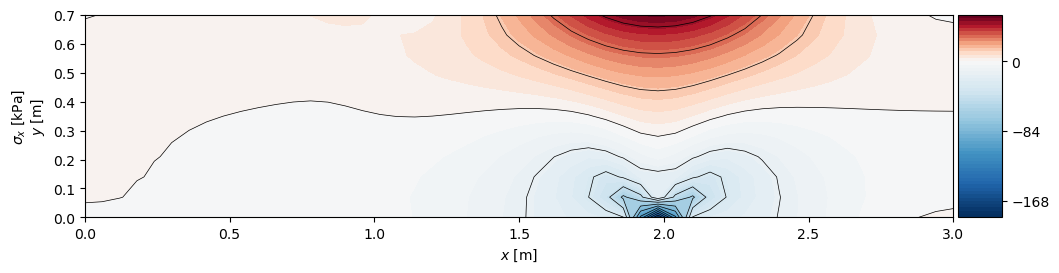

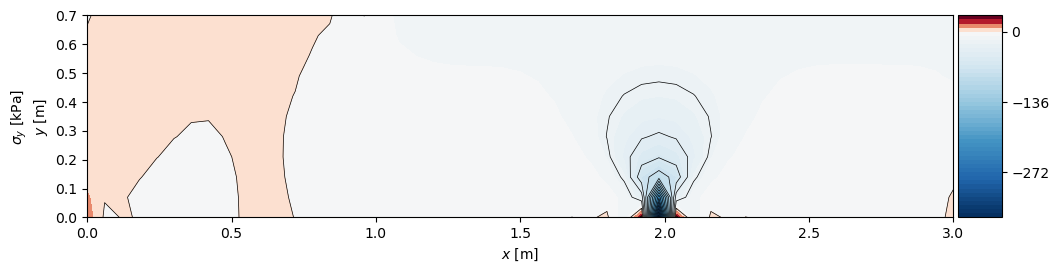

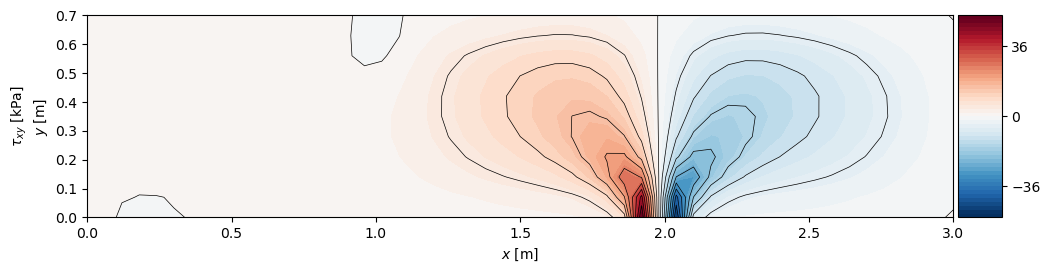

In [4]:
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["SX"], r"$\sigma_x$ [kPa]")
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["SY"], r"$\sigma_y$ [kPa]")
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["TXY"], r"$\tau_{xy}$ [kPa]")

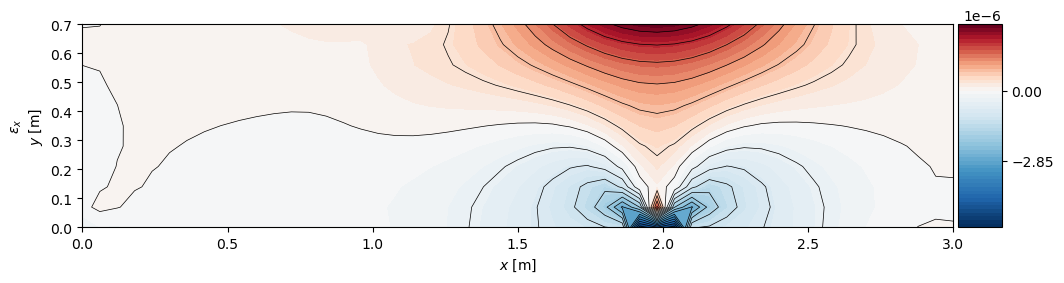

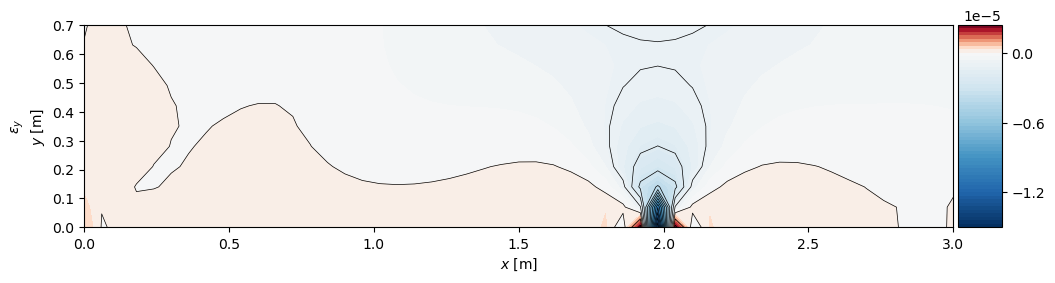

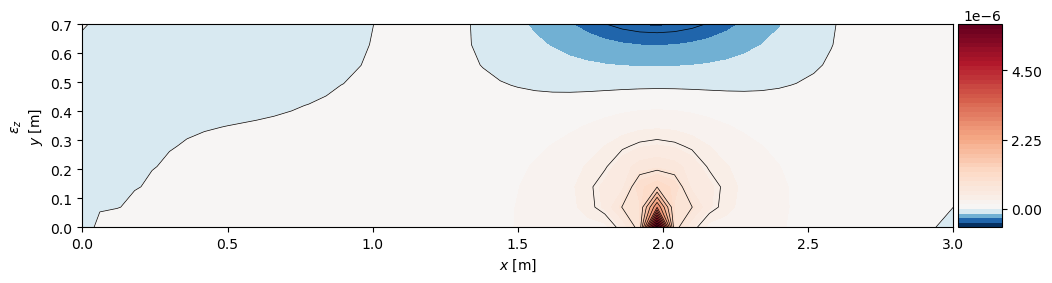

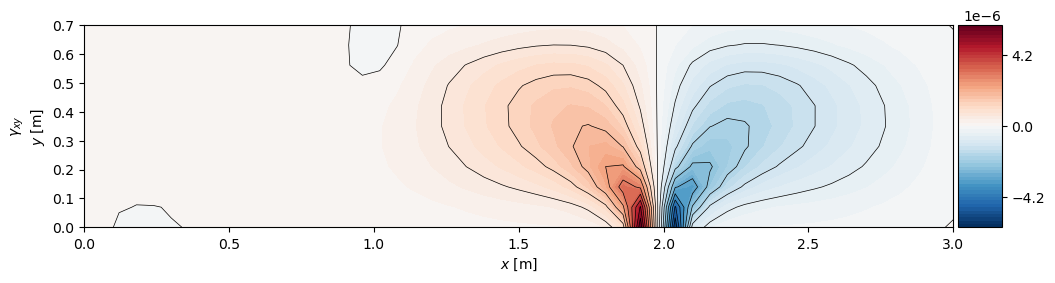

In [5]:
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["EX"], r"$\varepsilon_x$")
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["EY"], r"$\varepsilon_y$")
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["EZ"], r"$\varepsilon_z$")
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["GXY"], r"$\gamma_{xy}$")

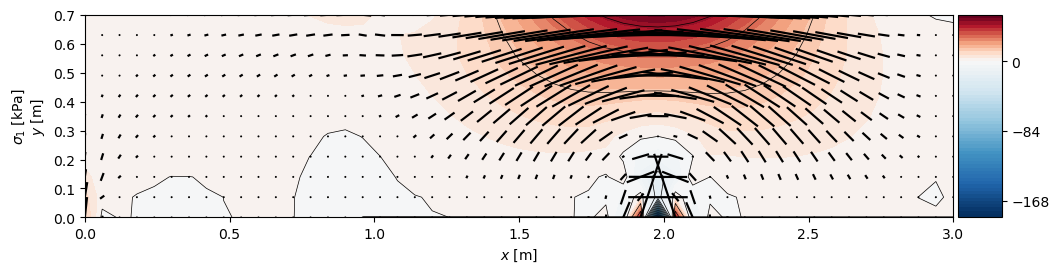

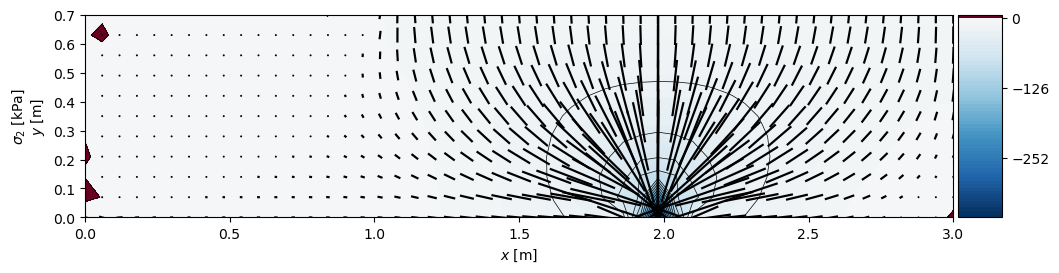

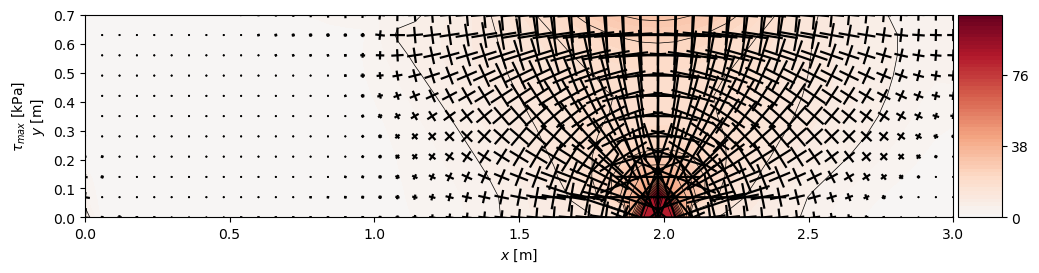

In [6]:
plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["S1"], r"$\sigma_1$ [kPa]", 
             angulo=diagramas["ANG_P1"])

plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["S2"], r"$\sigma_2$ [kPa]", 
             angulo=diagramas["ANG_P2"])

plot_esf_def(diagramas["X"], diagramas["Y"], diagramas["TMAX"], r"$\tau_{max}$ [kPa]", 
             angulo=[diagramas["ANG_P1"], diagramas["ANG_P2"]])

## Diagramas de fuerza cortante y momento flector

En los ejemplos anteriores de vigas, los esfuerzos se obtuvieron a partir de resolver la función de tensión de Airy, razón por la cual contábamos con expresiones analíticas para calcular las fuerzas internas directamente. En este caso, no disponemos de funciones analíticas, sino únicamente de resultados numéricos aproximados obtenidos por el método de los elementos finitos.

Esta es la razón por la que los diagramas de fuerza cortante y de momento flector pueden verse un poco irregulares. En particular, el diagrama de fuerza cortante no refleja con precisión el salto en $x = 2.0$ m, debido a la densidad de nodos en la dirección $x$. Si se requiriera un resultado más preciso, sería necesario aumentar la cantidad de elementos en esa dirección o realizar un refinamiento local de la malla en la zona cercana al apoyo.

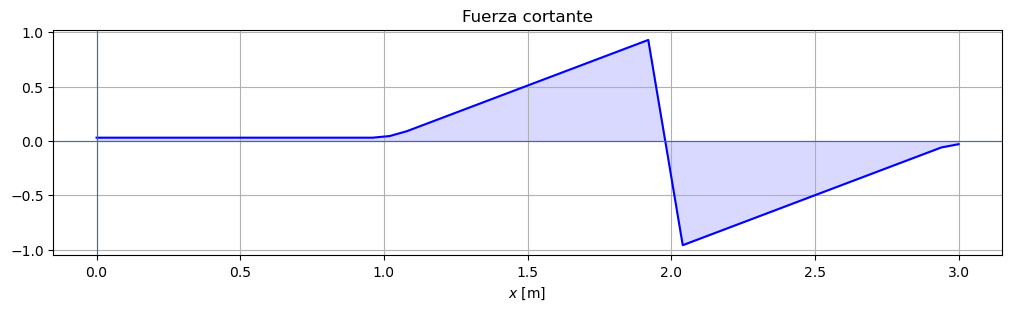

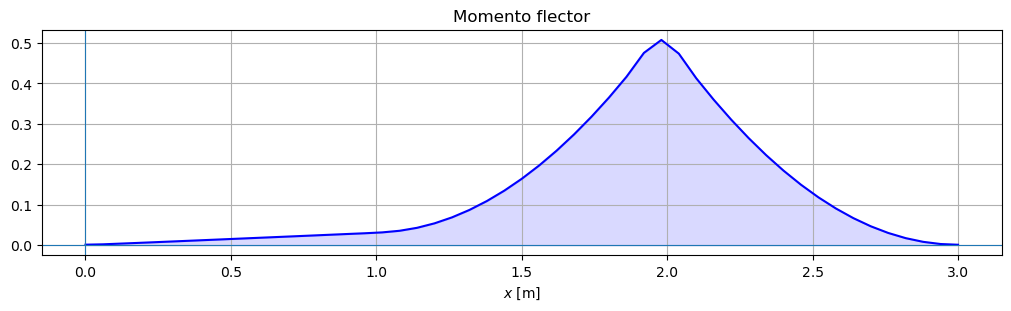

In [7]:
# Diagramas V y M
plot_v_m(diagramas["x_vec"], diagramas["V_diag"], titulo="Fuerza cortante")
plot_v_m(diagramas["x_vec"], diagramas["M_diag"], titulo="Momento flector")

In [8]:
# Verificación de equilibrio estático
f_vertical_total = np.sum(f[1::2]) / 1000 # Suma de todas las fuerzas en Y aplicadas
error = (R_Ay + R_By) + f_vertical_total
print(f"Suma de fuerzas verticales: {error:.4f} kN (Cercano a 0 = Equilibrio)")
print("-" * 30)

Suma de fuerzas verticales: -0.0000 kN (Cercano a 0 = Equilibrio)
------------------------------


## Trayectorias de esfuerzo

Para graficar estas trayectorias de esfuezo, al igual que en el caso de los diagramas de fuerza cortante y momento flector, no disponemos de funciones analíticas de los esfurezos. Deberemos hacer una aproximación numérica. 

**¿Cómo lo hacemos?**

La diferencia fundamental es que en el código analítico sx, sy, txy son funciones `lambda(x,y)`. Aquí tenemos arrays 2D nodales, por lo que la solución es construir interpoladores 2D sobre la malla estructurada Q4 y usarlos exactamente igual que las lambdas analíticas.